<center><h1>Zhu_Lingfei_HW2</h1></center>
<br>
<br>

Name: Zhu Lingfei
<br>
Github Username: youth0505
<br>
USC ID: 8599420339

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

Get the Cycle Power Plant Data Set

In [2]:
data = pd.read_excel("../data/CCPP/Folds5x2_pp.xlsx", sheet_name=0)
data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
data.shape

(9568, 5)

#### ii. pairwise scatterplots of all the varianbles

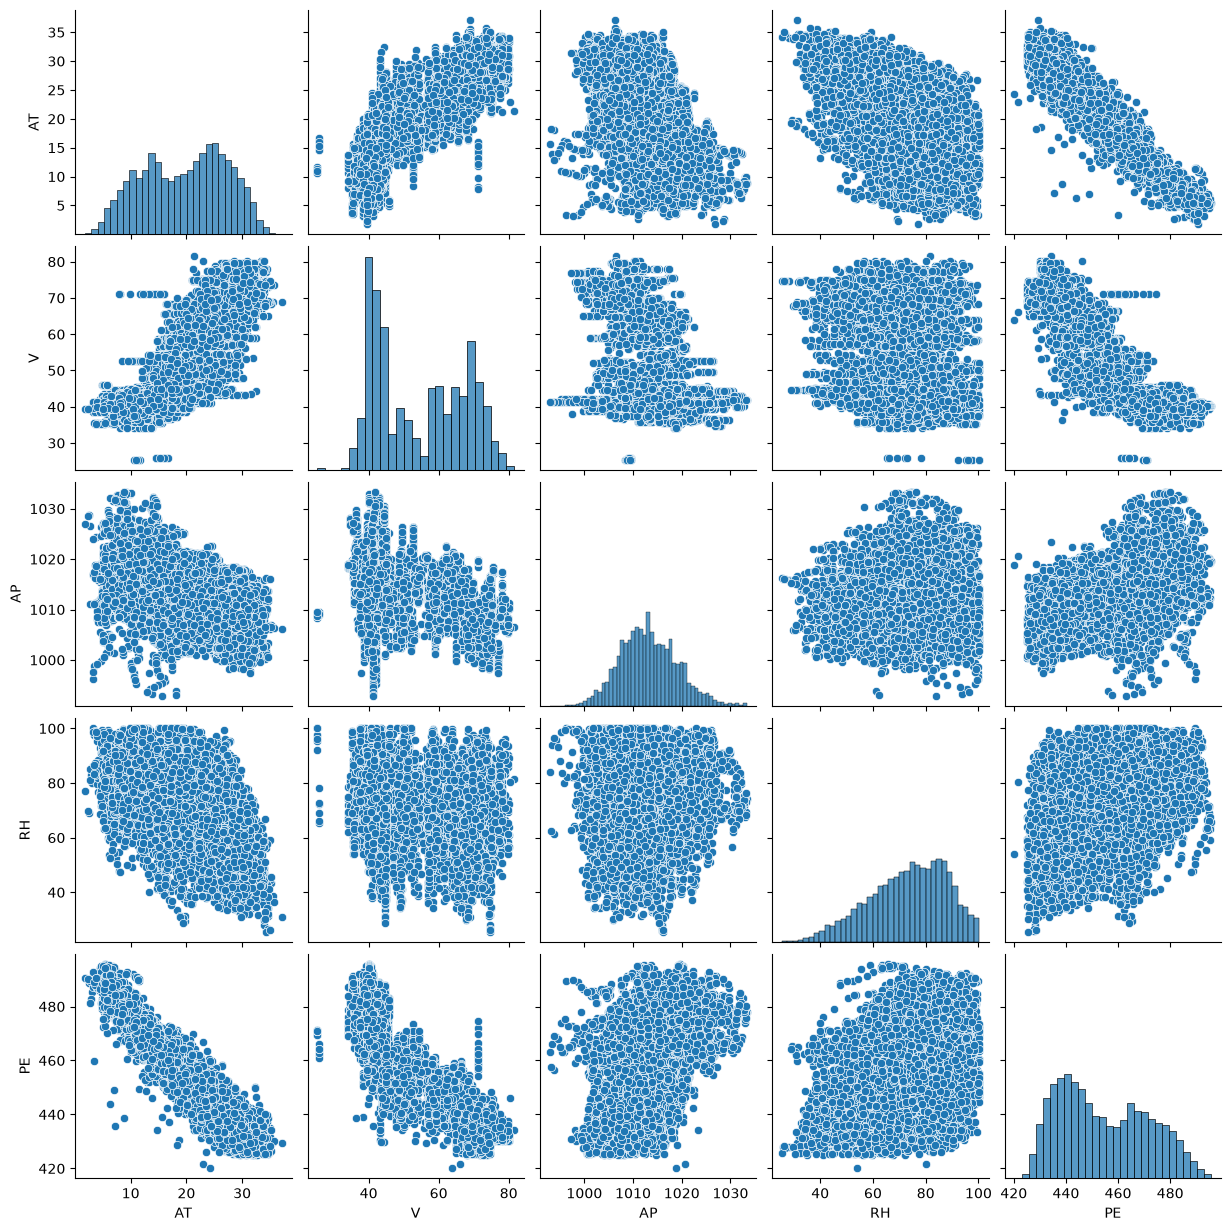

In [4]:
sns.pairplot(data)
plt.show()

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
summary = pd.DataFrame({
    "mean": data.mean(),
    "median": data.median(),
    "range": data.max() - data.min(),
    "Q1": data.quantile(0.25),
    "Q3": data.quantile(0.75),
    "IQR": data.quantile(0.75) - data.quantile(0.25)
})
summary

,mean,median,range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

In [6]:
predictors = ["AT", "V", "AP", "RH"]
simple_models = {}

for x in predictors:
    model = smf.ols(f"PE ~ {x}", data=data).fit()
    simple_models[x] = model
    print(x)
    print(model.summary())

AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:27:04   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280      

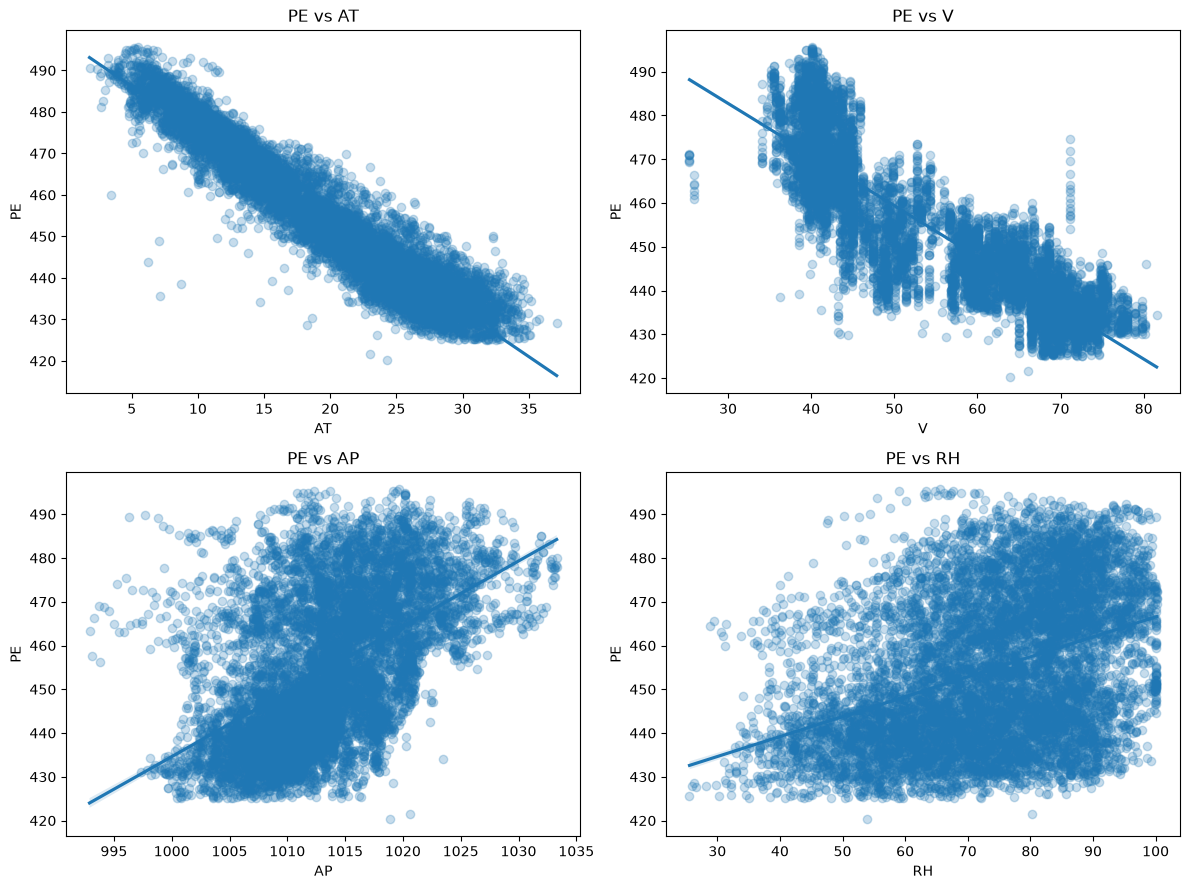

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, x in zip(axes.flat, predictors):
    sns.regplot(data=data, x=x, y="PE", ax=ax, scatter_kws={"alpha": 0.25})
    ax.set_title(f"PE vs {x}")

plt.tight_layout()
plt.show()

### (d) Multiple Regression

In [8]:
multiple_model = smf.ols("PE ~ AT + V + AP + RH", data=data).fit()
print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:27:05   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

### (e) 1c Compare to 1d

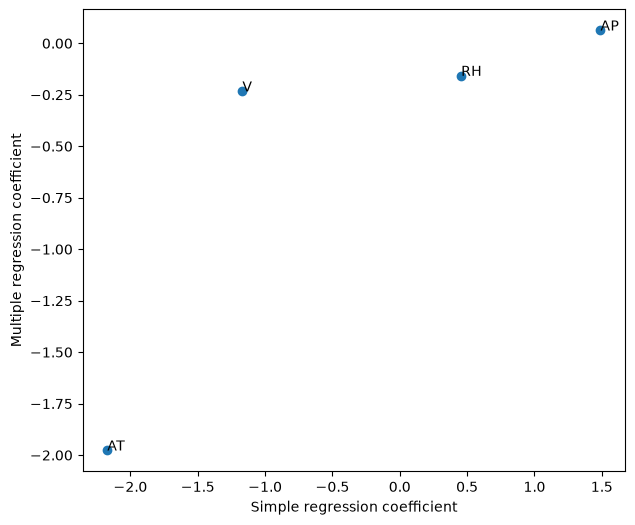

In [9]:
simple_coef = pd.Series({
    x: simple_models[x].params[x]
    for x in predictors
})

multiple_coef = multiple_model.params[predictors]

plt.figure(figsize=(7, 6))
plt.scatter(simple_coef, multiple_coef)

for x in predictors:
    plt.annotate(x, (simple_coef[x], multiple_coef[x]))

plt.xlabel("Simple regression coefficient")
plt.ylabel("Multiple regression coefficient")
plt.show()

### (f) Nonlinear Association

In [10]:
cubic_models = {}

for x in predictors:
    formula = f"PE ~ {x} + I({x} ** 2) + I({x} ** 3)"
    model = smf.ols(formula, data=data).fit()
    cubic_models[x] = model
    print(x)
    print(model.summary())

AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:27:06   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    492.7281      0.673    732.248      

### (g) Interactions of Predictors

In [11]:
interaction_model = smf.ols(
    "PE ~ (AT + V + AP + RH) ** 2",
    data=data
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:27:06   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

### (h) Improvement

In [12]:
train_data, test_data = train_test_split(
    data,
    test_size=0.3,
    random_state=1
)

In [13]:
linear_model = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=train_data
).fit()

train_pred_linear = linear_model.predict(train_data)
test_pred_linear = linear_model.predict(test_data)

linear_train_mse = mean_squared_error(train_data["PE"], train_pred_linear)
linear_test_mse = mean_squared_error(test_data["PE"], test_pred_linear)

linear_train_mse, linear_test_mse

(20.76611976145094, 20.777478106883713)

In [14]:
full_model = smf.ols(
    "PE ~ (AT + V + AP + RH) ** 2 + I(AT ** 2) + I(V ** 2) + I(AP ** 2) + I(RH ** 2)",
    data=train_data
).fit()

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7181.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:27:06   Log-Likelihood:                -19192.
No. Observations:                6697   AIC:                         3.841e+04
Df Residuals:                    6682   BIC:                         3.852e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8171.8080   1416.708     -5.768      0.0

### (i) KNN

In [15]:
X_train = train_data[predictors]
X_test = test_data[predictors]
y_train = train_data["PE"]
y_test = test_data["PE"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ks = range(1, 101)
train_errors_raw = []
test_errors_raw = []
train_errors_scaled = []
test_errors_scaled = []

for k in ks:
    model_raw = KNeighborsRegressor(n_neighbors=k)
    model_raw.fit(X_train, y_train)
    train_errors_raw.append(mean_squared_error(y_train, model_raw.predict(X_train)))
    test_errors_raw.append(mean_squared_error(y_test, model_raw.predict(X_test)))

    model_scaled = KNeighborsRegressor(n_neighbors=k)
    model_scaled.fit(X_train_scaled, y_train)
    train_errors_scaled.append(mean_squared_error(y_train, model_scaled.predict(X_train_scaled)))
    test_errors_scaled.append(mean_squared_error(y_test, model_scaled.predict(X_test_scaled)))

In [16]:
best_k_raw = ks[np.argmin(test_errors_raw)]
best_k_scaled = ks[np.argmin(test_errors_scaled)]

best_k_raw, min(test_errors_raw), best_k_scaled, min(test_errors_scaled)

(5, 15.704821203761764, 4, 14.070606067136888)

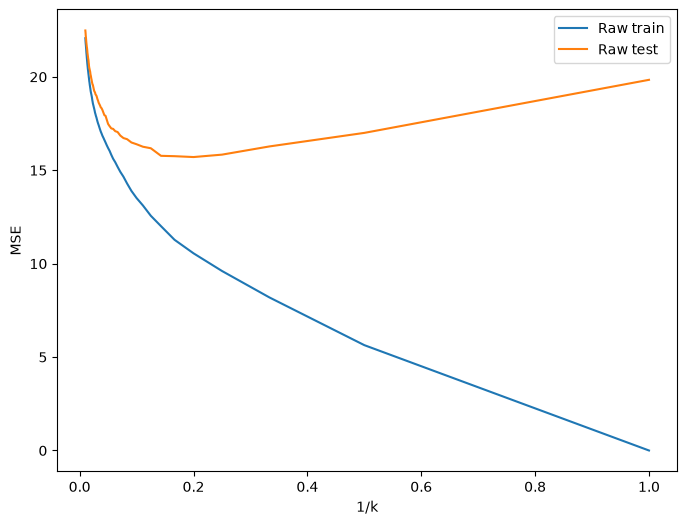

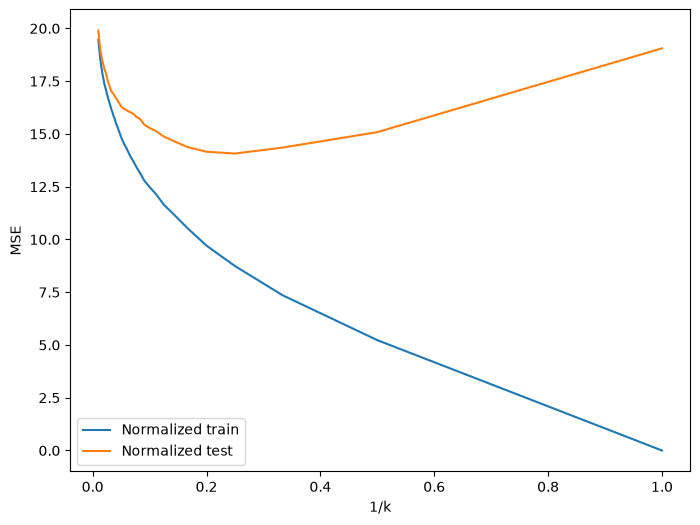

In [17]:
inverse_ks = [1 / k for k in ks]

plt.figure(figsize=(8, 6))
plt.plot(inverse_ks, train_errors_raw, label="Raw train")
plt.plot(inverse_ks, test_errors_raw, label="Raw test")
plt.xlabel("1/k")
plt.ylabel("MSE")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(inverse_ks, train_errors_scaled, label="Normalized train")
plt.plot(inverse_ks, test_errors_scaled, label="Normalized test")
plt.xlabel("1/k")
plt.ylabel("MSE")
plt.legend()
plt.show()

### (j ) Compare KNN and Linear

In [18]:
best_knn_raw_mse = min(test_errors_raw)
best_knn_scaled_mse = min(test_errors_scaled)

if best_knn_raw_mse < best_knn_scaled_mse:
    best_knn_mse = best_knn_raw_mse
    best_knn_k = best_k_raw
    best_knn_features = "raw"
else:
    best_knn_mse = best_knn_scaled_mse
    best_knn_k = best_k_scaled
    best_knn_features = "normalized"

if linear_test_mse < best_knn_mse:
    print(f"Linear regression has the lower test MSE: {linear_test_mse:.3f}")
    print(f"Best KNN test MSE: {best_knn_mse:.3f}, k={best_knn_k}, features={best_knn_features}")
else:
    print(f"KNN has the lower test MSE: {best_knn_mse:.3f}, k={best_knn_k}, features={best_knn_features}")
    print(f"Linear regression test MSE: {linear_test_mse:.3f}")

KNN has the lower test MSE: 14.071, k=4, features=normalized
Linear regression test MSE: 20.777


## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

Better. Since n is large and p is small, we have enough data to estimate the model without much risk of overfitting. A flexible method can capture patterns that a simpler model might miss.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

Worse. There are many predictors but few observations, so a flexible method could fit the training data too closely. An inflexible method is less likely to overfit. 

### (c) The relationship between the predictors and response is highly non-linear.

Better. A flexible method can fit a nonlinear relationship.  An inflexible method may be too simple to capture it.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

Worse. With high error variance, the response has a lot of noise. A flexible method may fit that noise, so an inflexible method would likely perform better on new data.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [19]:
X = np.array([
    [0, 3, 0],
    [2, 0, 0],
    [0, 1, 3],
    [0, 1, 2],
    [-1, 0, 1],
    [1, 1, 1]
])

test_point = np.array([0, 0, 0])
distances = np.sqrt(((X - test_point) ** 2).sum(axis=1))
distances

array([3.        , 2.        , 3.16227766, 2.23606798, 1.41421356,
       1.73205081])

### (b) What is our prediction with K = 1? Why?

In [20]:
y = np.array(["Red", "Red", "Red", "Green", "Green", "Red"])

In [21]:
nearest_index = np.argmin(distances)
prediction_k1 = y[nearest_index]
prediction_k1

np.str_('Green')

### (c) What is our prediction with K = 3? Why?

In [22]:
nearest_indices = np.argsort(distances)[:3]
prediction_k3 = pd.Series(y[nearest_indices]).mode()[0]
prediction_k3

'Red'

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

A small K would generally be preferred because it allows KNN to fit a more flexible decision boundary.